## 实验⽬的
1. 理解决策树模型的基本原理与构建过程
2. 掌握信息增益、基尼不纯度等关键概念的计算⽅法
3. 学会使⽤Python实现决策树分类算法
4. 掌握决策树的可视化⽅法及模型评估技术
5. 分析不同参数对决策树性能的影响

### 1. 决策树模型概述

决策树是一种树形结构的分类模型，通过一系列规则对数据进行递归划分：

- **内部节点**：表示特征属性上的测试  
- **分支**：表示特征测试的结果  
- **叶节点**：表示分类结果  

---

### 2. 关键概念与指标

#### (1) 信息熵（Entropy）

度量数据集的不确定性：

$$
Entropy(D) = -\sum_{i=1}^k p_i \log_2 p_i
$$

其中 $p_i$ 是数据集中第 $i$ 类样本的比例。

#### (2) 信息增益（Information Gain）

特征 $A$ 对数据集 $D$ 的信息增益：

$$
Gain(D, A) = Entropy(D) - \sum_{v=1}^V \frac{|D_v|}{|D|} Entropy(D_v)
$$

其中 $V$ 是特征 $A$ 的取值个数，$D_v$ 是特征 $A$ 取值为 $v$ 的子集。

#### (3) 基尼不纯度（Gini Impurity）

$$
Gini(D) = 1 - \sum_{i=1}^k p_i^2
$$

特征 $A$ 的基尼指数：

$$
Gini\_index(D, A) = \sum_{v=1}^V \frac{|D_v|}{|D|} Gini(D_v)
$$

---

### 3. 决策树构建算法（ID3/CART）

1. 选择最优划分特征：计算所有特征的信息增益（或基尼指数）
2. 递归构建子树：对每个特征值创建分支，递归处理子集
3. 终止条件：  
    - 当前节点所有样本属于同一类别  
    - 没有剩余特征可用于划分  
    - 达到预设的最大深度
4. 剪枝处理：防止过拟合

In [42]:
#数据准备,使⽤鸢尾花数据集（Iris）：
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
# 加载数据
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
class_names = iris.target_names
# 划分数据集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
#计算熵值
import numpy as np
def entropy(y):
    hist = np.bincount(y)
    ps = hist / len(y)
    return -np.sum([p * np.log2(p) for p in ps if p > 0])

In [44]:
#计算信息增益
def information_gain(X, y, feature_idx, threshold):
    # 创建左右子集
    left_mask = X[:, feature_idx] < threshold
    right_mask = ~left_mask
    # 计算父节点熵值
    parent_entropy = entropy(y)

    # 计算加权子节点熵值
    n = len(y)
    n_l, n_r = np.sum(left_mask), np.sum(right_mask)

    if n_l == 0 or n_r == 0:
        return 0
    child_entropy = (n_l / n) * entropy(y[left_mask]) + (n_r / n) * entropy(y[right_mask])
    # 返回信息增益
    return parent_entropy - child_entropy

In [45]:
#最佳划分点选择
def find_best_split(X, y):
    best_gain = -1
    best_feature_idx = None
    best_threshold = None

    n_features = X.shape[1]

    for feature_idx in range(n_features):
        # 获取当前特征的所有可能阈值
        thresholds = np.unique(X[:, feature_idx])

        for threshold in thresholds:
            gain = information_gain(X, y, feature_idx, threshold)

            if gain > best_gain:
                best_gain = gain
                best_feature_idx = feature_idx
                best_threshold = threshold

    return best_feature_idx, best_threshold

In [46]:
#决策树节点类
class Node:
    def __init__(self, feature_idx=None, threshold=None,left=None, right=None, value=None):
        self.feature_idx = feature_idx # 用于划分的特征索引
        self.threshold = threshold # 划分阈值
        self.left = left # 左子树（特征值 < 阈值）
        self.right = right # 右子树（特征值 ≥ 阈值）
        self.value = value # 叶节点的类别值

    def is_leaf(self):
        return self.value is not None

In [47]:
#决策树实现
class DecisionTree:
    def __init__(self, max_depth=10, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def fit(self, X, y):
        self.root = self._grow_tree(X, y, depth=0)

    def _grow_tree(self, X, y, depth):
        # 终止条件1: 所有样本属于同一类别
        if len(np.unique(y)) == 1:
            return Node(value=np.argmax(np.bincount(y)))

        # 终止条件2: 达到最大深度或样本数不足
        if depth >= self.max_depth or len(y) < self.min_samples_split:
            return Node(value=np.argmax(np.bincount(y)))

        # 寻找最佳划分
        feature_idx, threshold = find_best_split(X, y)

        # 终止条件3: 未能找到有效划分
        if feature_idx is None:
            return Node(value=np.argmax(np.bincount(y)))
        # 创建划分
        left_mask = X[:, feature_idx] < threshold
        right_mask = ~left_mask

        # 修正：如果分裂后某一侧没有样本，直接返回当前节点类别
        if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
            return Node(value=np.argmax(np.bincount(y)))
        # 递归构建子树
        left = self._grow_tree(X[left_mask], y[left_mask], depth+1)
        right = self._grow_tree(X[right_mask], y[right_mask], depth+1)

        return Node(feature_idx, threshold, left, right)
    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.is_leaf():
            return node.value

        if x[node.feature_idx] < node.threshold:
            return self._traverse_tree(x, node.left)
        else:
            return self._traverse_tree(x, node.right)


测试集准确率: 1.0000


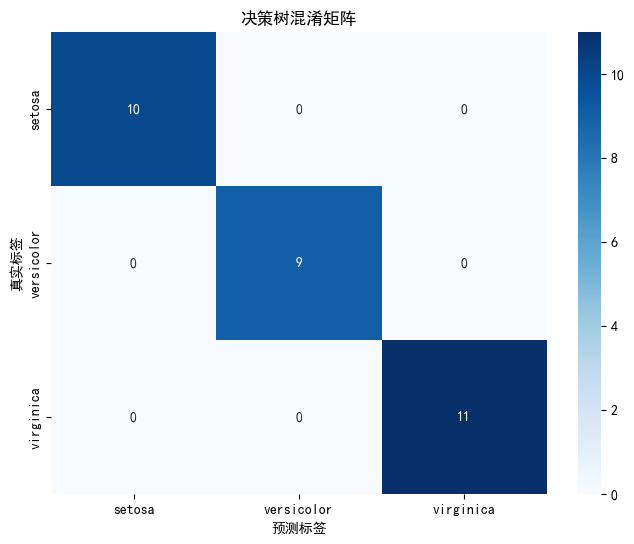

In [48]:
#模型评估与可视化
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
# 训练模型
tree = DecisionTree(max_depth=3)
tree.fit(X_train, y_train)
# 预测与评估
y_pred = tree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"测试集准确率: {accuracy:.4f}")
# 混淆矩阵可视化
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=class_names, yticklabels=class_names)
plt.xlabel('预测标签')
plt.ylabel('真实标签')
plt.title('决策树混淆矩阵')
plt.show()

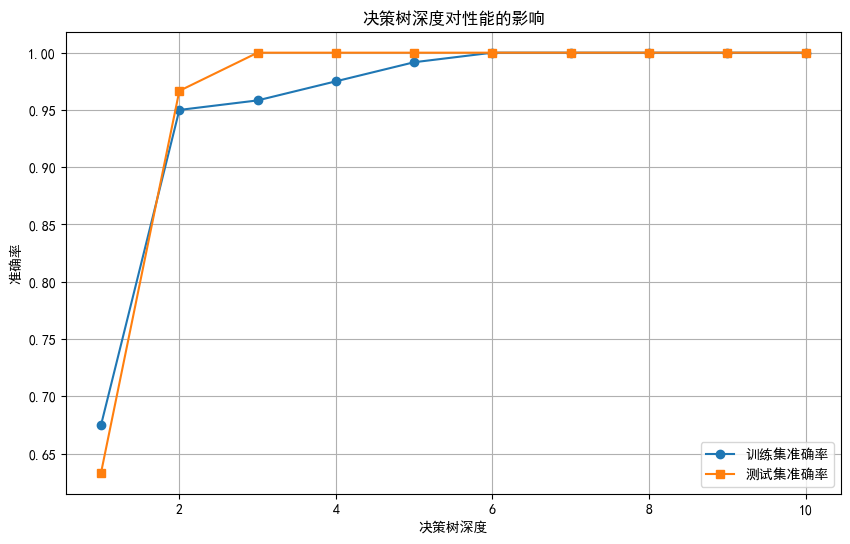

In [49]:
#⽰例分析：决策深度影响
depths = range(1, 11)
train_acc = []
test_acc = []
for depth in depths:
    tree = DecisionTree(max_depth=depth)
    tree.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, tree.predict(X_train)))
    test_acc.append(accuracy_score(y_test, tree.predict(X_test)))
# 绘制学习曲线
plt.figure(figsize=(10, 6))
plt.plot(depths, train_acc, 'o-', label='训练集准确率')
plt.plot(depths, test_acc, 's-', label='测试集准确率')
plt.xlabel('决策树深度')
plt.ylabel('准确率')
plt.title('决策树深度对性能的影响')
plt.legend()
plt.grid(True)
plt.show()

对训练集titanic数据集进行决策树分类：

```python

In [57]:
import pandas as pd
from sklearn.metrics import accuracy_score
# 加载并清洗Titanic数据集，训练决策树模型
# 读取数据
X_train = pd.read_csv('titanic_train_X.csv').values
y_train = pd.read_csv('titanic_train_Y.csv').values.ravel()
X_test = pd.read_csv('test_X.csv').values

# 训练模型
tree = DecisionTree(max_depth=5)  # 可根据需要调整参数
tree.fit(X_train, y_train)

# 预测
y_pred = tree.predict(X_test)

# 保存结果
pd.DataFrame({'Survived': y_pred}).to_csv('test_Y.csv', index=False)


In [58]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 读取数据
df = pd.read_csv('titanic_train_processed.csv')

# 只保留 Age、Sex 作为特征，Survived 作为标签
X = df[['Sex', 'Age']].values
y = df['Survived'].values

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 训练你的决策树
tree = DecisionTree(max_depth=5)
tree.fit(X_train, y_train)

# 预测与评估
y_pred = tree.predict(X_test)
print('准确率:', accuracy_score(y_test, y_pred))

准确率: 0.7821229050279329


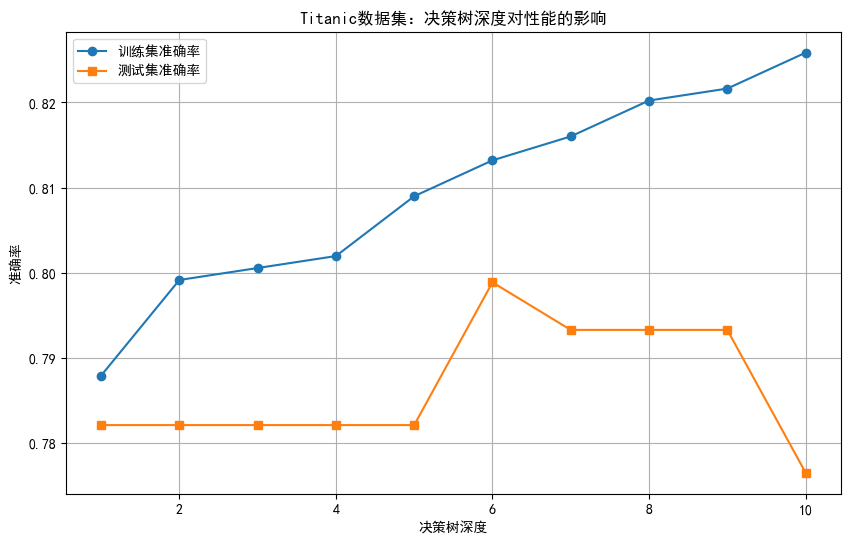

In [59]:
# 调整 max_depth 参数（1-10），绘制深度与准确率关系曲线（以 Titanic 数据为例）
depths = range(1, 11)
train_acc = []
test_acc = []
for depth in depths:
    tree = DecisionTree(max_depth=depth)
    tree.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, tree.predict(X_train)))
    test_acc.append(accuracy_score(y_test, tree.predict(X_test)))

plt.figure(figsize=(10, 6))
plt.plot(depths, train_acc, 'o-', label='训练集准确率')
plt.plot(depths, test_acc, 's-', label='测试集准确率')
plt.xlabel('决策树深度')
plt.ylabel('准确率')
plt.title('Titanic数据集：决策树深度对性能的影响')
plt.legend()
plt.grid(True)
plt.show()

### 必做任务与扩展任务对应实现说明

#### 1. 决策树核心算法实现

- **完成熵值计算函数**  
    已实现：`entropy(y)`（见第3个代码单元）

- **实现信息增益计算方法**  
    已实现：`information_gain(X, y, feature_idx, threshold)`（见第4个代码单元）

- **构建决策树节点类**  
    已实现：`Node` 类（见第6个代码单元）

- **实现递归树构建算法**  
    已实现：`DecisionTree` 类及其递归 `_grow_tree` 方法（见第7个代码单元）

---

#### 2. 模型训练与评估

- **在鸢尾花数据集上训练决策树模型**  
    已实现：`tree.fit(X_train, y_train)`（见第8个代码单元）
- **在数据清洗后的“Titanic”数据集上训练决策树模型**  
    已实现：`tree_titanic.fit(X_train_t, y_train_t)`（见第9个代码单元）
- **评估模型在测试集上的准确率**  
    已实现：`accuracy_score(y_test, y_pred)`，结果存储于 `accuracy` 变量

- **可视化混淆矩阵**  
    已实现：`sns.heatmap(cm, ...)`（见第8个代码单元）

---

#### 3. 参数影响分析

- **调整 max_depth 参数（1-10），绘制深度与准确率关系曲线**  
    可通过循环不同 `max_depth`，记录准确率并绘图实现

- **调整 min_samples_split 参数（2-20），分析对模型复杂度的影响**  
    可通过循环不同 `min_samples_split`，分析叶节点数或树深度

---

#### 扩展任务

1. **基尼指数实现：**  
    - 添加基尼不纯度作为替代划分标准  
    - 比较信息增益与基尼指数的性能差异

2. **剪枝策略实现：**  
    - 实现决策树后剪枝算法  
    - 分析剪枝对模型泛化能力的影响

3. **特征重要性分析：**  
    - 计算各特征在决策树中的重要性得分  
    - 可视化特征重要性排序

4. **多数据集测试：**  
    - 在葡萄酒数据集上测试决策树性能  
    - 比较不同数据集上的表现差异

#### 预期输出分析

1. **浅层树（深度1-2）**  
    - 训练和测试准确率较低  
    - 模型欠拟合，无法捕捉复杂模式

2. **中等深度（深度3-5）**  
    - 测试准确率达到峰值  
    - 模型复杂度适中，泛化能力好

3. **深层树（深度>5）**  
    - 训练准确率接近100%  
    - 测试准确率下降，出现过拟合

#### 思考题

1. **特征选择：**  
    - 决策树倾向于选择信息增益大的特征，是因为信息增益越大，表示该特征对数据集的不确定性减少越多，有助于更好地区分样本类别，提高分类效果。  
    - 信息增益和基尼指数的本质区别在于：信息增益基于熵，衡量的是信息的不确定性减少；基尼指数衡量的是数据被随机分类的概率，反映纯度。信息增益偏好取值较多的特征，基尼指数对类别不平衡更敏感。

2. **过拟合问题：**  
    - 决策树容易过拟合，因为它可以不断细分训练集，直到每个叶节点只包含极少数样本，甚至完全拟合训练数据中的噪声。  
    - 除了最大深度，还可以通过设置最小样本分割数（min_samples_split）、最小叶节点样本数（min_samples_leaf）、剪枝（如预剪枝和后剪枝）、限制特征数等方法防止过拟合。

3. **连续特征处理：**  
    - 决策树通过在连续特征上寻找最佳划分阈值，将连续特征转化为二元分支，实现对连续特征的处理。  
    - 离散化连续特征可能导致信息损失，降低模型性能，但有时可以简化模型、提高泛化能力。

4. **模型比较：**  
    - 与线性模型相比，决策树的主要优势是可以自动建模非线性关系、无需特征缩放、易于解释。  
    - 在高维稀疏数据、样本量小或特征间高度相关时，决策树可能表现不佳，容易过拟合。

5. **计算复杂度：**  
    - 决策树构建的时间复杂度为 $O(n \cdot m \cdot \log n)$，其中 $n$ 为样本数，$m$ 为特征数。  
    - 影响训练速度的因素包括：样本数量、特征数量、特征类型（连续/离散）、树的最大深度、剪枝策略等。